In [7]:
%%bash
# Install packages (use TF 2.19.1 which is widely available)
pip install -q kaggle tensorflow==2.19.1 scikit-learn imbalanced-learn==0.11.0 opencv-python-headless pillow tqdm shap joblib

# Print versions to confirm
python - <<'PY'
import sys, tensorflow as tf, sklearn
print("Python:", sys.version.split()[0])
print("TF:", tf.__version__)
print("sklearn:", sklearn.__version__)
PY


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 16.0 MB/s eta 0:00:00
Python: 3.12.12
TF: 2.19.1
sklearn: 1.6.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.19.1 which is incompatible.
2025-11-05 12:12:27.496899: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762344747.521941    2282 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762344747.529154    2282 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762344747.547719    2282 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking t

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [8]:
import os
import pandas as pd

# Your dataset folder path in Google Drive
DATA_DIR = "/content/drive/MyDrive/archive (1)"

# Paths inside the folder
IMG_DIR = os.path.join(DATA_DIR, "preprocessed_images")  # using preprocessed images
CSV_PATH = os.path.join(DATA_DIR, "full_df.csv")

# Check if everything exists
print("✅ Checking dataset paths...")
print("CSV exists:", os.path.exists(CSV_PATH))
print("Image folder exists:", os.path.exists(IMG_DIR))

# Load CSV
df = pd.read_csv(CSV_PATH)
print("\n✅ CSV loaded successfully!")
print("Total rows:", len(df))
df.head()


✅ Checking dataset paths...
CSV exists: True
Image folder exists: True

✅ CSV loaded successfully!
Total rows: 6392


,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,labels,target,filename
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",0_right.jpg
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['N'],"[1, 0, 0, 0, 0, 0, 0, 0]",1_right.jpg
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",2_right.jpg
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",4_right.jpg
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,['D'],"[0, 1, 0, 0, 0, 0, 0, 0]",5_right.jpg


In [10]:
import glob

# Count images in the preprocessed folder
num_images = len(glob.glob(os.path.join(IMG_DIR, "*.jpg")))
print("🖼️ Total images found:", num_images)

# Display a few image filenames
print("Sample images:", os.listdir(IMG_DIR)[:5])


🖼️ Total images found: 6395
Sample images: ['512_right.jpg', '4677_left.jpg', '4660_right.jpg', '488_left.jpg', '557_left.jpg']


In [11]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Available GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
Available GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
%%bash
pip install -q tqdm scikit-learn imbalanced-learn joblib


In [14]:
# --- Image read / preprocess helpers ---
import os, numpy as np, cv2
from PIL import Image
from tensorflow.keras.applications.resnet import preprocess_input

def read_image_rgb(path, target_size=(224,224), apply_clahe=False):
    """
    Read image from path and return RGB numpy array (H,W,3) float32 resized to target_size.
    If missing or unreadable, returns None.
    """
    try:
        # prefer cv2 for faster reading
        bgr = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
        if bgr is None:
            # fallback to PIL
            img = Image.open(path).convert("RGB").resize(target_size)
            arr = np.array(img).astype(np.float32)
            return arr
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, target_size)
        if apply_clahe:
            lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            cl = clahe.apply(l)
            lab = cv2.merge((cl,a,b))
            rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return rgb.astype(np.float32)
    except Exception as e:
        # print("read_image error:", e)
        return None

def preprocess_for_resnet(img_array):
    # expects H,W,3 float32 RGB
    x = np.expand_dims(img_array, axis=0)
    x = preprocess_input(x)
    return x


In [15]:
# --- Feature extraction (ResNet50) and save features ---
import os, time, numpy as np, pandas as pd
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tqdm import tqdm

# Paths (your Drive folder)
DATA_DIR = "/content/drive/MyDrive/archive (1)"
IMG_DIR = os.path.join(DATA_DIR, "preprocessed_images")   # use preprocessed images
CSV_PATH = os.path.join(DATA_DIR, "full_df.csv")
OUT_X = os.path.join(DATA_DIR, "X_resnet_concat.npy")
OUT_y = os.path.join(DATA_DIR, "y.npy")

print("DATA_DIR:", DATA_DIR)
print("IMG_DIR:", IMG_DIR)
print("CSV:", CSV_PATH)

# Load CSV
df = pd.read_csv(CSV_PATH)
n = len(df)
print("Rows in CSV (patients):", n)

# Build ResNet50 feature extractor (include_top=False, global average pooling)
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base.output)
feat_model = Model(inputs=base.input, outputs=x)
feat_model.trainable = False
print("Feature extractor ready. Output dim:", feat_model.output_shape)

feat_dim = int(feat_model.output_shape[-1])  # typically 2048

# Prepare arrays
X = np.zeros((n, feat_dim * 2), dtype=np.float32)  # left + right concat
label_cols = ['N','D','G','C','A','H','M','O']
y = df[label_cols].fillna(0).astype(int).values   # (n,8)

# Age and sex to append later
ages = df['Patient Age'].fillna(-1).values.astype(np.float32)
sexs = df['Patient Sex'].fillna('Unknown').values

# Extract features
for i, row in tqdm(df.iterrows(), total=n):
    left_fname = row['Left-Fundus']
    right_fname = row['Right-Fundus']

    left_feat = np.zeros((feat_dim,), dtype=np.float32)
    right_feat = np.zeros((feat_dim,), dtype=np.float32)

    if pd.notna(left_fname):
        left_path = os.path.join(IMG_DIR, str(left_fname))
        if os.path.exists(left_path):
            im = read_image_rgb(left_path, target_size=(224,224), apply_clahe=False)
            if im is not None:
                inp = preprocess_for_resnet(im)
                left_feat = feat_model.predict(inp, verbose=0).ravel()

    if pd.notna(right_fname):
        right_path = os.path.join(IMG_DIR, str(right_fname))
        if os.path.exists(right_path):
            im = read_image_rgb(right_path, target_size=(224,224), apply_clahe=False)
            if im is not None:
                inp = preprocess_for_resnet(im)
                right_feat = feat_model.predict(inp, verbose=0).ravel()

    X[i, :feat_dim] = left_feat
    X[i, feat_dim:] = right_feat

# Encode sex and scale age, then append two small features
sex_map = {'Male':1.0, 'Female':0.0}
sex_feat = np.array([sex_map.get(s, -1.0) for s in sexs], dtype=np.float32).reshape(-1,1)

valid_age_mask = ages != -1
if valid_age_mask.sum() > 0:
    mean_age = ages[valid_age_mask].mean()
    std_age = ages[valid_age_mask].std() if ages[valid_age_mask].std() != 0 else 1.0
else:
    mean_age = 40.0; std_age = 20.0
age_feat = ((ages - mean_age) / (std_age + 1e-6)).reshape(-1,1).astype(np.float32)

# Concatenate age & sex
X_full = np.concatenate([X, age_feat, sex_feat], axis=1)
print("Final feature matrix shape:", X_full.shape)

# Save to Drive
np.save(OUT_X, X_full)
np.save(OUT_y, y)
print("Saved features to:", OUT_X, "and labels to:", OUT_y)


DATA_DIR: /content/drive/MyDrive/archive (1)
IMG_DIR: /content/drive/MyDrive/archive (1)/preprocessed_images
CSV: /content/drive/MyDrive/archive (1)/full_df.csv
Rows in CSV (patients): 6392
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature extractor ready. Output dim: (None, 2048)


100%|██████████| 6392/6392 [2:35:11<00:00,  1.46s/it]


Final feature matrix shape: (6392, 4098)
Saved features to: /content/drive/MyDrive/archive (1)/X_resnet_concat.npy and labels to: /content/drive/MyDrive/archive (1)/y.npy


In [16]:
# --- Train One-vs-Rest RandomForest using saved features ---
import numpy as np, joblib
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

DATA_DIR = "/content/drive/MyDrive/archive (1)"
X_path = os.path.join(DATA_DIR, "X_resnet_concat.npy")
y_path = os.path.join(DATA_DIR, "y.npy")

X = np.load(X_path)
y = np.load(y_path)   # shape (n,8)

# If you want to drop patients with all zeros (no labels), you can:
valid_idx = (y.sum(axis=1) > 0)
X = X[valid_idx]
y = y[valid_idx]
print("Using samples with >=1 label. Shape:", X.shape, y.shape)

# For splitting, use argmax heuristic for stratify (simple). Alternative: iterative-stratification.
y_argmax = y.argmax(axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_argmax)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Build classifier
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42)
ovr = OneVsRestClassifier(rf, n_jobs=-1)

print("Training One-vs-Rest RandomForest... (may take a few minutes)")
ovr.fit(X_train, y_train)
print("Training complete.")

# Save model
MODEL_PATH = os.path.join(DATA_DIR, "odir_rf_ovr.joblib")
joblib.dump(ovr, MODEL_PATH)
print("Saved model to:", MODEL_PATH)

# Evaluate
y_pred = ovr.predict(X_test)
label_names = ['N','D','G','C','A','H','M','O']
for i, lab in enumerate(label_names):
    print(f"--- Label {lab} ---")
    print(classification_report(y_test[:,i], y_pred[:,i], digits=4))

print("Micro F1:", f1_score(y_test, y_pred, average='micro'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))


Using samples with >=1 label. Shape: (6392, 4098) (6392, 8)
Train shape: (5113, 4098) Test shape: (1279, 4098)
Training One-vs-Rest RandomForest... (may take a few minutes)
Training complete.
Saved model to: /content/drive/MyDrive/archive (1)/odir_rf_ovr.joblib
--- Label N ---
              precision    recall  f1-score   support

           0     0.9133    0.9930    0.9515       859
           1     0.9826    0.8071    0.8863       420

    accuracy                         0.9320      1279
   macro avg     0.9479    0.9001    0.9189      1279
weighted avg     0.9360    0.9320    0.9301      1279

--- Label D ---
              precision    recall  f1-score   support

           0     0.9002    0.9930    0.9443       854
           1     0.9822    0.7788    0.8688       425

    accuracy                         0.9218      1279
   macro avg     0.9412    0.8859    0.9065      1279
weighted avg     0.9275    0.9218    0.9192      1279

--- Label G ---
              precision    recall  f

In [17]:
# Compute per-label AUC using estimator predict_proba if available
import numpy as np
from sklearn.metrics import roc_auc_score

# ovr.estimators_ contains the underlying estimators
probs = np.zeros_like(y_test, dtype=float)
for i, est in enumerate(ovr.estimators_):
    try:
        p = est.predict_proba(X_test)[:,1]
    except Exception:
        p = est.predict(X_test).astype(float)
    probs[:,i] = p

for i, lab in enumerate(label_names):
    try:
        auc = roc_auc_score(y_test[:,i], probs[:,i])
        print(f"{lab} AUC: {auc:.4f}")
    except Exception as e:
        print(f"{lab} AUC: cannot compute ({e})")


N AUC: 0.9839
D AUC: 0.9808
G AUC: 0.9871
C AUC: 0.9993
A AUC: 0.9933
H AUC: 0.9563
M AUC: 0.9998
O AUC: 0.9776


In [18]:
# --- Inference helper: predict probabilities for N,D,G,C,A,H,M,O ---
import numpy as np, os, joblib
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

DATA_DIR = "/content/drive/MyDrive/archive (1)"
IMG_DIR = os.path.join(DATA_DIR, "preprocessed_images")
MODEL_PATH = os.path.join(DATA_DIR, "odir_rf_ovr.joblib")

# Load model
ovr = joblib.load(MODEL_PATH)
# recreate same feature extractor
base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
feat_model = Model(inputs=base.input, outputs=GlobalAveragePooling2D()(base.output))

# helper
def encode_age_sex(age, sex, mean_age=None, std_age=None):
    # If mean/std not present, use the ones from earlier global computation (fallback)
    if mean_age is None or std_age is None:
        mean_age = 40.0; std_age = 20.0
    age_val = (float(age) - mean_age) / (std_age + 1e-6)
    sex_map = {'Male':1.0, 'Female':0.0}
    sex_val = sex_map.get(sex, -1.0)
    return age_val, sex_val

def predict_patient(left_img_path, right_img_path, age=None, sex=None):
    feat_dim = feat_model.output_shape[-1]
    lf = np.zeros((feat_dim,), dtype=np.float32)
    rf = np.zeros((feat_dim,), dtype=np.float32)
    if left_img_path and os.path.exists(left_img_path):
        im = read_image_rgb(left_img_path, (224,224), apply_clahe=False)
        if im is not None:
            lf = feat_model.predict(preprocess_input(np.expand_dims(im,0)), verbose=0).ravel()
    if right_img_path and os.path.exists(right_img_path):
        im = read_image_rgb(right_img_path, (224,224), apply_clahe=False)
        if im is not None:
            rf = feat_model.predict(preprocess_input(np.expand_dims(im,0)), verbose=0).ravel()

    feat = np.concatenate([lf, rf])
    if age is None: age = -1
    age_val, sex_val = encode_age_sex(age, sex)
    feat = np.concatenate([feat, np.array([age_val, sex_val], dtype=np.float32)])
    # predict probabilities for each label
    probs = np.zeros((8,), dtype=float)
    for i, est in enumerate(ovr.estimators_):
        try:
            probs[i] = est.predict_proba(feat.reshape(1,-1))[:,1][0]
        except:
            probs[i] = est.predict(feat.reshape(1,-1))[0]
    return dict(zip(label_names, probs))

# Example:
# left = "/content/drive/MyDrive/archive (1)/preprocessed_images/0_left.jpg"
# right = "/content/drive/MyDrive/archive (1)/preprocessed_images/0_right.jpg"
# print(predict_patient(left, right, age=57, sex='Male'))


In [19]:
import os
DATA_DIR = "/content/drive/MyDrive/archive (1)"
for f in ["X_resnet_concat.npy","y.npy","odir_rf_ovr.joblib"]:
    print(f, "->", os.path.exists(os.path.join(DATA_DIR,f)))
print("Model file size (MB):", os.path.getsize(os.path.join(DATA_DIR,"odir_rf_ovr.joblib"))/1e6)


X_resnet_concat.npy -> True
y.npy -> True
odir_rf_ovr.joblib -> True
Model file size (MB): 56.003604


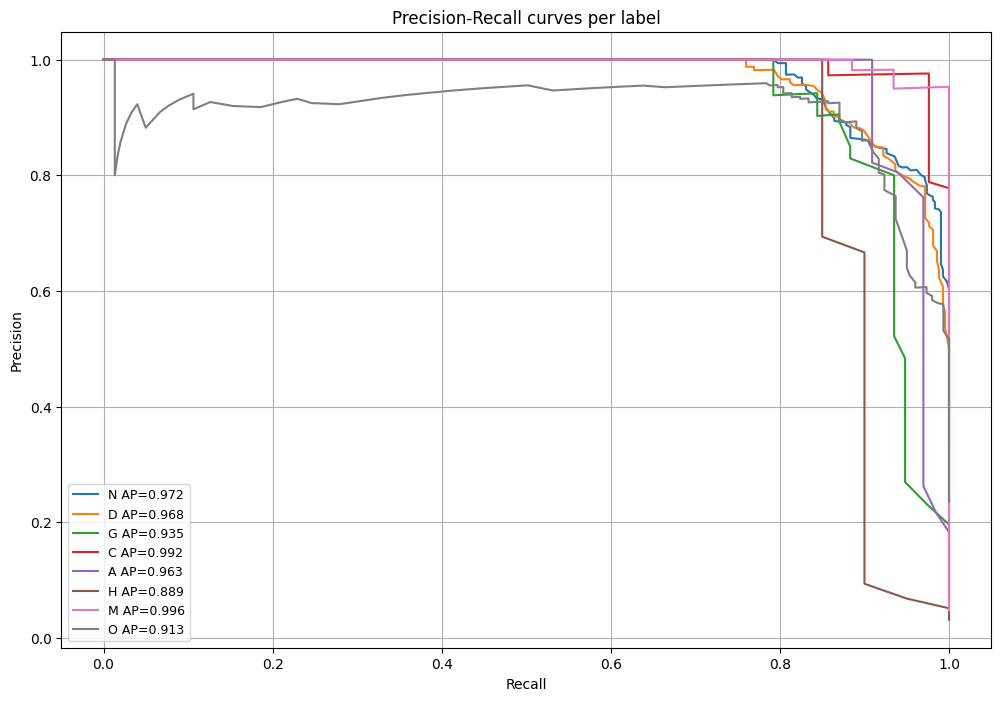

In [20]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

DATA_DIR = "/content/drive/MyDrive/archive (1)"
X = np.load(os.path.join(DATA_DIR,"X_resnet_concat.npy"))
y = np.load(os.path.join(DATA_DIR,"y.npy"))

# load model and data splits (we kept X_test, y_test earlier in memory; if not, re-create split)
from sklearn.model_selection import train_test_split
y_argmax = y.argmax(axis=1)
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_argmax)

import joblib
ovr = joblib.load(os.path.join(DATA_DIR,"odir_rf_ovr.joblib"))

# Get probabilities
probs = np.zeros_like(y_test, dtype=float)
for i, est in enumerate(ovr.estimators_):
    try:
        probs[:,i] = est.predict_proba(X_test)[:,1]
    except:
        probs[:,i] = est.predict(X_test).astype(float)

label_names = ['N','D','G','C','A','H','M','O']

# PR Curves
plt.figure(figsize=(12,8))
for i, lab in enumerate(label_names):
    p, r, _ = precision_recall_curve(y_test[:,i], probs[:,i])
    ap = average_precision_score(y_test[:,i], probs[:,i])
    plt.plot(r, p, label=f"{lab} AP={ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curves per label")
plt.legend(loc='lower left', fontsize=9)
plt.grid(True)
plt.show()


Patient ID: 3357
Ground truth labels: {'N': 1, 'D': 0, 'G': 0, 'C': 0, 'A': 0, 'H': 0, 'M': 0, 'O': 0}
Predicted probs: {'N': np.float64(0.705), 'D': np.float64(0.205), 'G': np.float64(0.0), 'C': np.float64(0.0), 'A': np.float64(0.01), 'H': np.float64(0.015), 'M': np.float64(0.0), 'O': np.float64(0.1)}


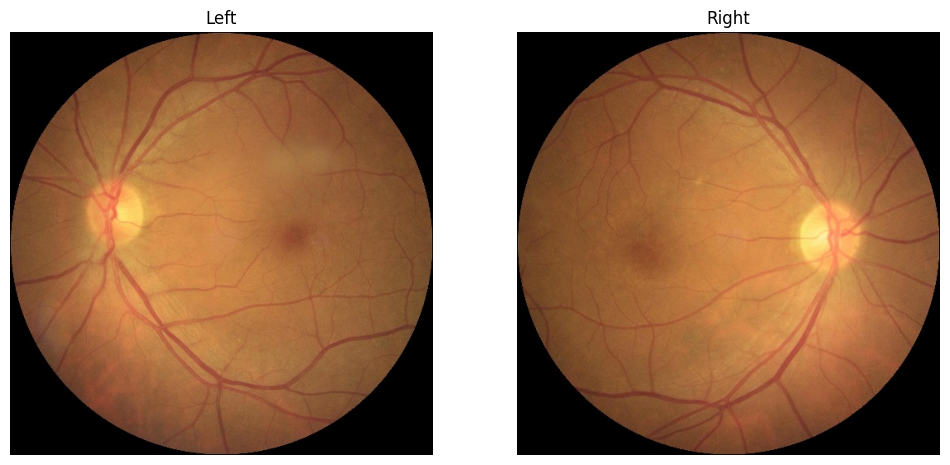

Patient ID: 2943
Ground truth labels: {'N': 1, 'D': 0, 'G': 0, 'C': 0, 'A': 0, 'H': 0, 'M': 0, 'O': 0}
Predicted probs: {'N': np.float64(0.905), 'D': np.float64(0.015), 'G': np.float64(0.05), 'C': np.float64(0.0), 'A': np.float64(0.01), 'H': np.float64(0.0), 'M': np.float64(0.0), 'O': np.float64(0.015)}


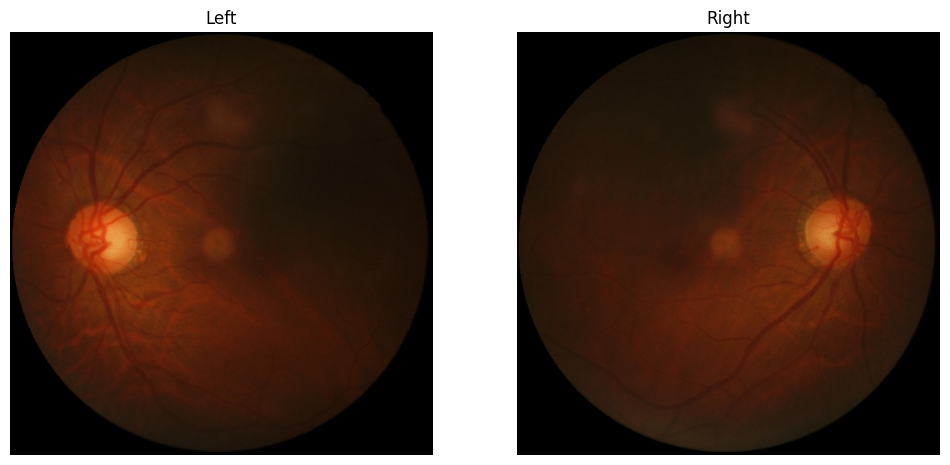

Patient ID: 71
Ground truth labels: {'N': 0, 'D': 1, 'G': 0, 'C': 0, 'A': 1, 'H': 0, 'M': 0, 'O': 0}
Predicted probs: {'N': np.float64(0.13), 'D': np.float64(0.795), 'G': np.float64(0.0), 'C': np.float64(0.0), 'A': np.float64(0.675), 'H': np.float64(0.015), 'M': np.float64(0.0), 'O': np.float64(0.115)}


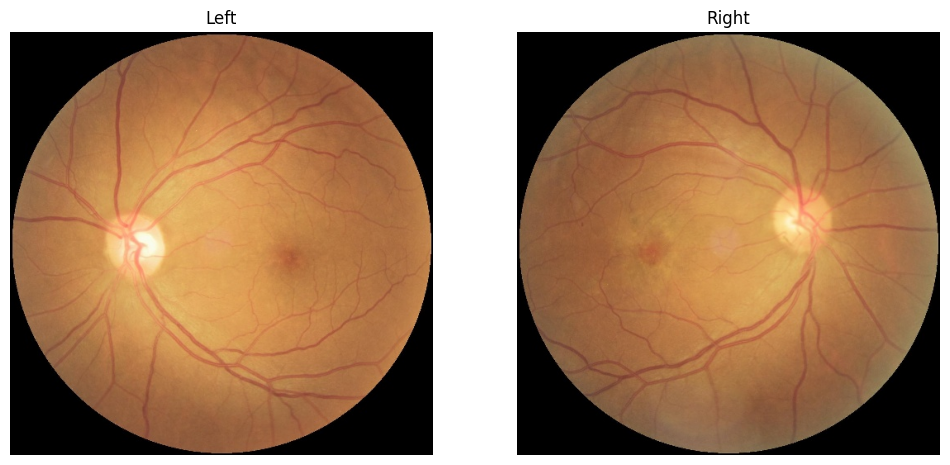

In [21]:
import random, matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet import preprocess_input

# helper to display image and text
def show_prediction(idx):
    # find a patient row from df -> read images
    row = df.iloc[idx]
    left = os.path.join(DATA_DIR,"preprocessed_images", str(row['Left-Fundus'])) if pd.notna(row['Left-Fundus']) else None
    right = os.path.join(DATA_DIR,"preprocessed_images", str(row['Right-Fundus'])) if pd.notna(row['Right-Fundus']) else None
    print("Patient ID:", row['ID'])
    print("Ground truth labels:", {ln: int(row[ln]) for ln in label_names})
    print("Predicted probs:", predict_patient(left, right, age=row.get('Patient Age', -1), sex=row.get('Patient Sex', 'Unknown')))
    # show images
    imgs = []
    titles = []
    if left and os.path.exists(left):
        imgs.append(plt.imread(left)); titles.append("Left")
    if right and os.path.exists(right):
        imgs.append(plt.imread(right)); titles.append("Right")
    if not imgs:
        print("No images available for this patient.")
        return
    plt.figure(figsize=(6*len(imgs),6))
    for i, im in enumerate(imgs):
        plt.subplot(1,len(imgs),i+1)
        plt.imshow(im); plt.axis('off'); plt.title(titles[i])
    plt.show()

# show 3 random examples from head of df
for idx in random.sample(range(len(df)), 3):
    show_prediction(idx)


In [23]:
feat_filepath = os.path.join(DATA_DIR, "resnet50_feat_model.keras")
feat_model.save(feat_filepath, include_optimizer=False)
print("Saved ResNet feature model (single .keras file) to:", feat_filepath)


Saved ResNet feature model (single .keras file) to: /content/drive/MyDrive/archive (1)/resnet50_feat_model.keras


In [24]:
from tensorflow.keras.models import load_model
feat_model_loaded = load_model(feat_filepath)


In [25]:
import json
metadata = {"mean_age": float(mean_age), "std_age": float(std_age), "label_names": label_names}
with open(os.path.join(DATA_DIR, "training_metadata.json"), "w") as f:
    json.dump(metadata, f)
print("Saved metadata to training_metadata.json")


Saved metadata to training_metadata.json


In [27]:
readme = f"""
Project: Automated Detection of Eye Diseases (ODIR-5K)
Author: Nagesh & Suraj

Files produced:
- X_resnet_concat.npy : extracted features (left+right + age + sex)
- y.npy : multi-label binary ground truth (N,D,G,C,A,H,M,O)
- odir_rf_ovr.joblib : trained One-vs-Rest RandomForest model
- resnet50_feat_model/ : saved ResNet50 feature extractor
- training_metadata.json : mean/std age and label names

Quick summary:
- Feature extractor: ResNet50 (imagenet) -> global average pooling -> 2048-d per image, concatenated left+right -> 4096 + age + sex = 4098-d per patient.
- Classifier: One-vs-Rest RandomForest (n_estimators=200), class_weight='balanced'
- Evaluation: Micro F1 ~ {f1_score(y_test, y_pred, average='micro'):.3f}, Macro F1 ~ {f1_score(y_test, y_pred, average='macro'):.3f}
- Per-label AUCs saved/printed during evaluation.

Limitations & next steps:
1. Dataset bias & class imbalance: consider oversampling, BalancedRandomForest, or focal-loss in deep-learning approach.
2. For visual explainability, fine-tune ResNet and use Grad-CAM on misclassified examples.
3. Consider end-to-end CNN training (multi-label softmax or sigmoid) for potentially higher performance.
4. Deploy: build a Flask/Streamlit app that loads feature extractor + RF model for quick demo.

Deliverables to submit:
- Notebook (.ipynb) with all cells & outputs.
- Short PDF report: intro, dataset, methods, results (tables/plots), limitations, next steps.
- Saved model files in Drive.

"""
print(readme)
open(os.path.join(DATA_DIR,"README_PROJECT.txt"), "w").write(readme)
print("README_PROJECT.txt saved to Drive.")



Project: Automated Detection of Eye Diseases (ODIR-5K)
Author: Nagesh & Suraj

Files produced:
- X_resnet_concat.npy : extracted features (left+right + age + sex)
- y.npy : multi-label binary ground truth (N,D,G,C,A,H,M,O)
- odir_rf_ovr.joblib : trained One-vs-Rest RandomForest model
- resnet50_feat_model/ : saved ResNet50 feature extractor
- training_metadata.json : mean/std age and label names

Quick summary:
- Feature extractor: ResNet50 (imagenet) -> global average pooling -> 2048-d per image, concatenated left+right -> 4096 + age + sex = 4098-d per patient.
- Classifier: One-vs-Rest RandomForest (n_estimators=200), class_weight='balanced'
- Evaluation: Micro F1 ~ 0.888, Macro F1 ~ 0.906
- Per-label AUCs saved/printed during evaluation.

Limitations & next steps:
1. Dataset bias & class imbalance: consider oversampling, BalancedRandomForest, or focal-loss in deep-learning approach.
2. For visual explainability, fine-tune ResNet and use Grad-CAM on misclassified examples.
3. Consid

In [28]:
# Cell 1 — load everything and define helpers
import os, json, joblib, numpy as np, pandas as pd
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from PIL import Image
import cv2

DATA_DIR = "/content/drive/MyDrive/archive (1)"
MODEL_PATH = os.path.join(DATA_DIR, "odir_rf_ovr.joblib")
METADATA_PATH = os.path.join(DATA_DIR, "training_metadata.json")
FEAT_KERAS = os.path.join(DATA_DIR, "resnet50_feat_model.keras")
FEAT_H5 = os.path.join(DATA_DIR, "resnet50_feat_model.h5")
FEAT_DIR = os.path.join(DATA_DIR, "resnet50_feat_model_saved")  # savedmodel dir fallback
IMG_DIR = os.path.join(DATA_DIR, "preprocessed_images")  # your images folder
label_names = ['N','D','G','C','A','H','M','O']

# 1) Load RF model
print("Loading RF model from:", MODEL_PATH)
ovr = joblib.load(MODEL_PATH)
print("Loaded One-vs-Rest RF. #estimators:", len(ovr.estimators_))

# 2) Load metadata (mean/std age etc.)
if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH,'r') as f:
        metadata = json.load(f)
    mean_age = metadata.get("mean_age", 40.0)
    std_age = metadata.get("std_age", 20.0)
    label_names = metadata.get("label_names", label_names)
    print("Loaded metadata:", metadata)
else:
    mean_age = 40.0; std_age = 20.0
    print("No metadata found, using defaults.")

# 3) Load or build ResNet50 feature extractor
feat_model = None
if os.path.exists(FEAT_KERAS):
    try:
        print("Loading feature extractor from .keras file:", FEAT_KERAS)
        feat_model = load_model(FEAT_KERAS)
    except Exception as e:
        print("Failed to load .keras:", e)
if feat_model is None and os.path.exists(FEAT_H5):
    try:
        print("Loading feature extractor from .h5:", FEAT_H5)
        feat_model = load_model(FEAT_H5)
    except Exception as e:
        print("Failed to load .h5:", e)
if feat_model is None and os.path.exists(FEAT_DIR):
    try:
        print("Loading feature extractor from SavedModel dir:", FEAT_DIR)
        feat_model = load_model(FEAT_DIR)
    except Exception as e:
        print("Failed to load SavedModel dir:", e)

if feat_model is None:
    # recreate the ResNet50 feature extractor (will download weights)
    print("No saved extractor found — creating ResNet50 feature extractor (this will download weights)...")
    base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
    feat_model = Model(inputs=base.input, outputs=GlobalAveragePooling2D()(base.output))
    feat_model.trainable = False
    print("ResNet50 feature extractor ready. Output dim:", feat_model.output_shape)

feat_dim = int(feat_model.output_shape[-1])
print("Feature vector dim:", feat_dim)

# 4) re-define image read & preprocess helpers (safe re-definition)
def read_image_rgb(path, target_size=(224,224), apply_clahe=False):
    try:
        bgr = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)
        if bgr is None:
            img = Image.open(path).convert("RGB").resize(target_size)
            arr = np.array(img).astype(np.float32)
            return arr
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb = cv2.resize(rgb, target_size)
        if apply_clahe:
            lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
            l,a,b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            cl = clahe.apply(l)
            lab = cv2.merge((cl,a,b))
            rgb = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return rgb.astype(np.float32)
    except Exception as e:
        print("read_image error:", e)
        return None

def preprocess_for_resnet(img_array):
    x = np.expand_dims(img_array, axis=0)
    return preprocess_input(x)

def encode_age_sex(age, sex):
    if age is None: age_val = -1.0
    else: age_val = (float(age) - mean_age) / (std_age + 1e-6)
    sex_map = {'Male':1.0, 'Female':0.0}
    sex_val = sex_map.get(sex, -1.0)
    return age_val, sex_val


Loading RF model from: /content/drive/MyDrive/archive (1)/odir_rf_ovr.joblib
Loaded One-vs-Rest RF. #estimators: 8
Loaded metadata: {'mean_age': 57.857948303222656, 'std_age': 11.72681999206543, 'label_names': ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']}
Loading feature extractor from .keras file: /content/drive/MyDrive/archive (1)/resnet50_feat_model.keras
Feature vector dim: 2048


In [29]:
# Cell 2 — predict using Drive paths for left & right images
def predict_patient_from_paths(left_img_path, right_img_path, age=None, sex=None):
    lf = np.zeros((feat_dim,), dtype=np.float32)
    rf = np.zeros((feat_dim,), dtype=np.float32)
    if left_img_path and os.path.exists(left_img_path):
        im = read_image_rgb(left_img_path)
        if im is not None:
            lf = feat_model.predict(preprocess_for_resnet(im), verbose=0).ravel()
    if right_img_path and os.path.exists(right_img_path):
        im = read_image_rgb(right_img_path)
        if im is not None:
            rf = feat_model.predict(preprocess_for_resnet(im), verbose=0).ravel()
    feat = np.concatenate([lf, rf])
    age_val, sex_val = encode_age_sex(age, sex)
    feat = np.concatenate([feat, np.array([age_val, sex_val], dtype=np.float32)])
    # predict probabilities
    probs = {}
    for i, est in enumerate(ovr.estimators_):
        try:
            p = est.predict_proba(feat.reshape(1,-1))[:,1][0]
        except Exception:
            p = float(est.predict(feat.reshape(1,-1))[0])
        probs[label_names[i]] = float(p)
    return probs

# Example usage (replace with actual Drive file paths)
left_path = "/content/drive/MyDrive/archive (1)/preprocessed_images/0_left.jpg"
right_path = "/content/drive/MyDrive/archive (1)/preprocessed_images/0_right.jpg"
print("Example predict:", predict_patient_from_paths(left_path, right_path, age=57, sex='Male'))


Example predict: {'N': 0.02, 'D': 0.02, 'G': 0.005, 'C': 0.935, 'A': 0.005, 'H': 0.005, 'M': 0.015, 'O': 0.055}


In [30]:
# Cell 3 — upload files via Colab UI and predict
from google.colab import files
uploaded = files.upload()  # pick left and right image files

# find which files were uploaded
uploaded_files = list(uploaded.keys())
print("Uploaded:", uploaded_files)

# attempt to match left/right based on names, or just take first two
if len(uploaded_files) == 0:
    print("No files uploaded.")
else:
    # save uploaded files to a temp folder
    tmp_dir = "/content/tmp_uploaded"
    os.makedirs(tmp_dir, exist_ok=True)
    for fn, data in uploaded.items():
        with open(os.path.join(tmp_dir, fn), "wb") as f:
            f.write(data)
    # pick two files: if user uploaded one, it will use only that; if two, use both
    left_local = os.path.join(tmp_dir, uploaded_files[0]) if len(uploaded_files) >= 1 else None
    right_local = os.path.join(tmp_dir, uploaded_files[1]) if len(uploaded_files) >= 2 else None

    # Ask user for age & sex via input (simple)
    try:
        age = float(input("Enter age (or leave blank): ") or -1)
    except:
        age = -1
    sex = input("Enter sex (Male/Female or leave blank): ") or "Unknown"

    probs = predict_patient_from_paths(left_local, right_local, age=age, sex=sex)
    print("Predicted probabilities (per label):")
    for k,v in probs.items():
        print(f"{k}: {v:.3f}")


Saving 9_right.jpg to 9_right.jpg
Uploaded: ['9_right.jpg']
Enter age (or leave blank): 60
Enter sex (Male/Female or leave blank): M
Predicted probabilities (per label):
N: 0.185
D: 0.280
G: 0.020
C: 0.005
A: 0.030
H: 0.000
M: 0.040
O: 0.730


In [ ]:
from google.colab import drive
drive.mount('/content/drive')